# Exercises 4

## Exercise 4.1

We are asked to include in the NSL simulator the calculation of Maxwell-Boltzmann distribution.

The Maxwell-Boltzmann distribution in Lennard-Jones units is:
$$p(v,T) = \left( \frac{m}{2\pi T} \right)^{3/2} 4\pi v^2 e^{-\frac{m v^2}{2 T}}$$

To compute the distribution we can sample the velocities of particles and plot an histogram against the theoretical distribution. 

To make the histogram we need to divide the velocities in ranges and count how many particles fall in each range. We have to limit the distribution to a maximum velocity $v_\text{max} = 4 \sqrt{T}$ (in LJ units), so we can use a finite number of bins. All velocities above this value will not be recorder, this cut is a good approximation because the Maxwell-Boltzmann distribution probability is a decreasing exponential for large velocities.

In [1]:
# Imports
from cycler import cycler

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import scienceplots

plt.style.use(["science", "ieee"])

colors = plt.cm.Set2.colors
plt.rcParams["axes.prop_cycle"] = cycler(color=colors)

plt.rcParams["figure.dpi"] = 300

In [2]:
def boltzmann(v: np.ndarray[float], T: float) -> np.ndarray[float]:
    """Analytical solution for the Maxwell-Boltzmann distribution"""
    return 4 * np.pi * v**2 * np.exp(-(v**2) / (2 * T)) / (2 * np.pi * T) ** 1.5

In the following figure is shown the histogram, with errors, of the particles velocities and the theoretical curve from the analitycal solution, both in LJ units. The simulation was executed with 100 steps per block, and 50 blocks.

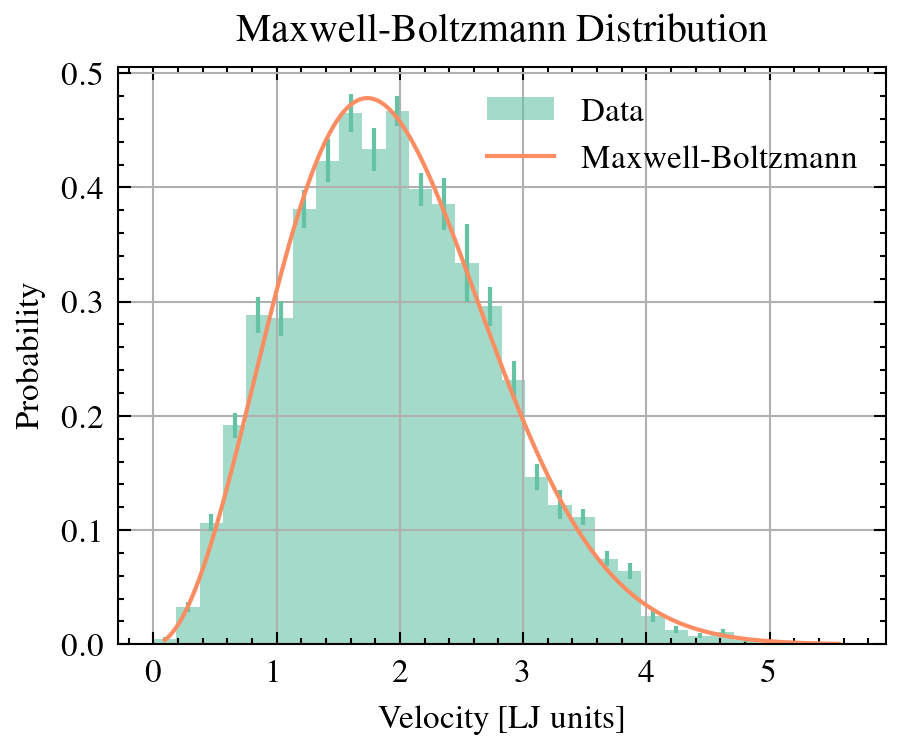

In [3]:
# ---------- Load data ----------
filename = "./Exer_04_01/OUTPUT/pofv.dat"
with open(filename, "r") as f:
    text = f.readline()
    binsize = float(text.split()[-1])

data = np.loadtxt(filename, skiprows=2)  # pofv

p_of_v = data[:, 2]
error = data[:, 3]

# final temperature
temp = np.loadtxt("./Exer_04_01/OUTPUT/temperature.dat")[-1, 2]

# ---------- Clean data ----------
block_number = max(data[:, 0])
mask = data[:, 0] == block_number

velocities = binsize * (np.arange(len(p_of_v[mask])) + 0.5)
bins = np.linspace(0, binsize * len(velocities), len(velocities) + 1)

vel_dense = np.linspace(min(velocities), max(velocities), 300)

# ---------- Plot ----------
plt.hist(velocities, bins=bins, weights=p_of_v[mask], alpha=0.6, label="Data")
plt.errorbar(velocities, p_of_v[mask], yerr=error[mask], fmt="none")  # to add errors

plt.plot(vel_dense, boltzmann(vel_dense, temp), label="Maxwell-Boltzmann")


plt.legend()
plt.grid(True)

plt.xlabel("Velocity [LJ units]")
plt.ylabel("Probability")
plt.title("Maxwell-Boltzmann Distribution")

plt.show()

## Exercise 4.2

We are then asked to start the simulation from a very low entropic initial configuration, let the system evolve and show that it has converged to Maxwell-Boltmann distribution.

To show this convergence I plotted the velocity distribution after 1, 10, and 100 blocks of the simulation, each block had 100 steps.

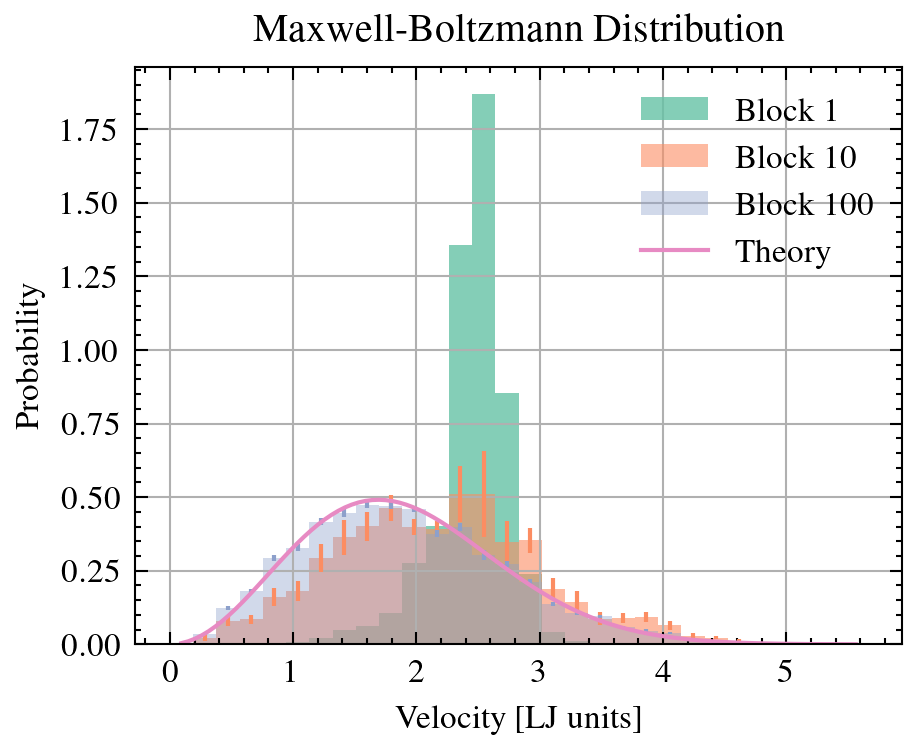

In [4]:
colors = iter(plt.rcParams["axes.prop_cycle"])

# ---------- Load data ----------
with open("./Exer_04_02/OUTPUT/pofv.dat", "r") as f:
    text = f.readline()
    binsize = float(text.split()[-1])

data = np.loadtxt("./Exer_04_02/OUTPUT/pofv.dat", skiprows=2)

# ---------- Clean data ----------
avg = data[:, 2]
err = data[:, 3]

blk = int(max(data[:, 0]))

mask1 = data[:, 0] == 1
mask2 = data[:, 0] == 10
mask3 = data[:, 0] == blk

n_bins = len(avg[mask1])
x = binsize * (np.arange(n_bins) + 0.5)
bins = np.linspace(0, binsize * n_bins, n_bins + 1)

# ---------- Plots ----------
clr = next(colors)["color"]
plt.hist(x, bins=bins, weights=avg[mask1], alpha=0.8, label=f"Block 1", color=clr)
# No errorbar for block 1

clr = next(colors)["color"]
plt.hist(x, bins=bins, weights=avg[mask2], alpha=0.6, label=f"Block 10", color=clr)
plt.errorbar(x, avg[mask2], yerr=err[mask2], fmt="none", ecolor=clr)

clr = next(colors)["color"]
plt.hist(x, bins=bins, weights=avg[mask3], alpha=0.4, label=f"Block {blk}", color=clr)
plt.errorbar(x, avg[mask3], yerr=err[mask3], fmt="none", ecolor=clr)

# ---------- Theory ----------
temp = np.loadtxt("./Exer_04_02/OUTPUT/temperature.dat")[-1, 2]

clr = next(colors)["color"]
x_dense = np.linspace(min(x), max(x), 100)
plt.plot(x_dense, boltzmann(x_dense, temp), color=clr, label="Theory")

# ---------- Style ----------
plt.legend()
plt.grid(True)

plt.xlabel("Velocity [LJ units]")
plt.ylabel("Probability")
plt.title("Maxwell-Boltzmann Distribution")

plt.show()

We can see that after the first block the particles don't have the same velocity anymore, but the majority of them are still near the staring value $v_0 = \sqrt{3T} \approx 2.5\mathrm{[LJ units]}$ (where $T$ is the temperature and all particles mass are set to $m=1$). After 10 blocks the velocities are more spread out, but a small peak at $v = 2.5$ is still visible. After 100 blocks the velocities have reached the Maxwell-Boltzmann distribution, and no secondary peaks are visible.

We can also use external tools like *Ovito* to make a simple animation of our particles evolving in time. Below is gif of a simulation with 5000 steps, we can see that they start in a low entropic configuration and assume a more homogeneous configuration over time.

![forward](./media/forward1.gif)

## Exercise 4.3

We are asked to make two simulations one with $5000$ steps and one with $50000$ steps, then invert time and check if they reach the low entropic starting configuration.

### Time Reverse

To invert the direction of time we just saved the last two configurations of particle position for the forward simulations, then we restarted the simulation with last configuration given by the second last of the forward, and the second last configuration given by the last configuration of the forward simulation.

### Verlet  ODE Integration

In our simulator we are using the Verlet ODE integrator, which gives us energy conservation for the simulations. By definition the Verlet integrator is simmetric on time reversal, so we expect to see our backward simulations reach the forward starting point.

### First Simulation (5000 steps)

For the sake of a better understanding I will first show the results of the first simulation (both forward and backward), comment it and then show the second simulation.

In [5]:
# Helper functions
def load_data(base_dir: str, run_name: str, quantity: str) -> np.ndarray[float]:
    """Load a .dat file for a given run and quantity."""
    path = f"{base_dir}/{run_name}/{quantity}.dat"
    return np.loadtxt(path)


def plot_quantity(
    base_dir: str,
    forward_run: str,
    backward_run: str,
    quantity: str,
    ylabel: str,
    show_average: bool,
    reverse_forward: bool,
) -> None:
    """Plot a single quantity for forward and backward simulations."""

    # Load data
    forward_data = load_data(base_dir, forward_run, quantity)
    backward_data = load_data(base_dir, backward_run, quantity)

    blocks = np.arange(1, len(forward_data) + 1)

    # Clean labels (remove trailing index like "forward1" -> "forward")
    forward_label = forward_run.rstrip("0123456789")
    backward_label = backward_run.rstrip("0123456789")

    # Optionally reverse forward data
    if reverse_forward:
        forward_data = forward_data[::-1]
        forward_label += " (reversed)"

    # Plots
    plt.figure()

    if show_average:
        # Reduce clutter if too many blocks
        error_step = 5 if len(blocks) > 100 else 1

        plt.errorbar(
            blocks,
            forward_data[:, 2],
            yerr=forward_data[:, 3],
            label=forward_label.title(),
            errorevery=error_step,
        )
        plt.errorbar(
            blocks,
            backward_data[:, 2],
            yerr=backward_data[:, 3],
            label=backward_label.title(),
            errorevery=error_step,
        )

        plt.title(f"{ylabel}: Average over Blocks")

    else:
        plt.plot(blocks, forward_data[:, 1], label=forward_label.title())
        plt.plot(blocks, backward_data[:, 1], label=backward_label.title())

        plt.title(f"{ylabel}: Single Block Averages")

    plt.xlabel("Block number")
    plt.ylabel(f"{ylabel} [LJ units]")

    plt.legend()
    plt.grid(True)

    plt.show()


def plot_forward_backward(
    base_dir: str,
    forward_run: str,
    backward_run: str,
    show_average: bool = True,
    reverse_forward: bool = False,
) -> None:
    """Plot multiple quantities for forward and backward runs."""

    # list of tuples (filename, label)
    quantities = [
        ("temperature", "Temperature"),
        ("potential_energy", "Potential Energy"),
        # ("kinetic_energy", "Kinetic Energy"),
    ]

    # call plot quantity for all tuples in quantities
    for quantity, label in quantities:
        plot_quantity(
            base_dir,
            forward_run,
            backward_run,
            quantity,
            label,
            show_average,
            reverse_forward,
        )

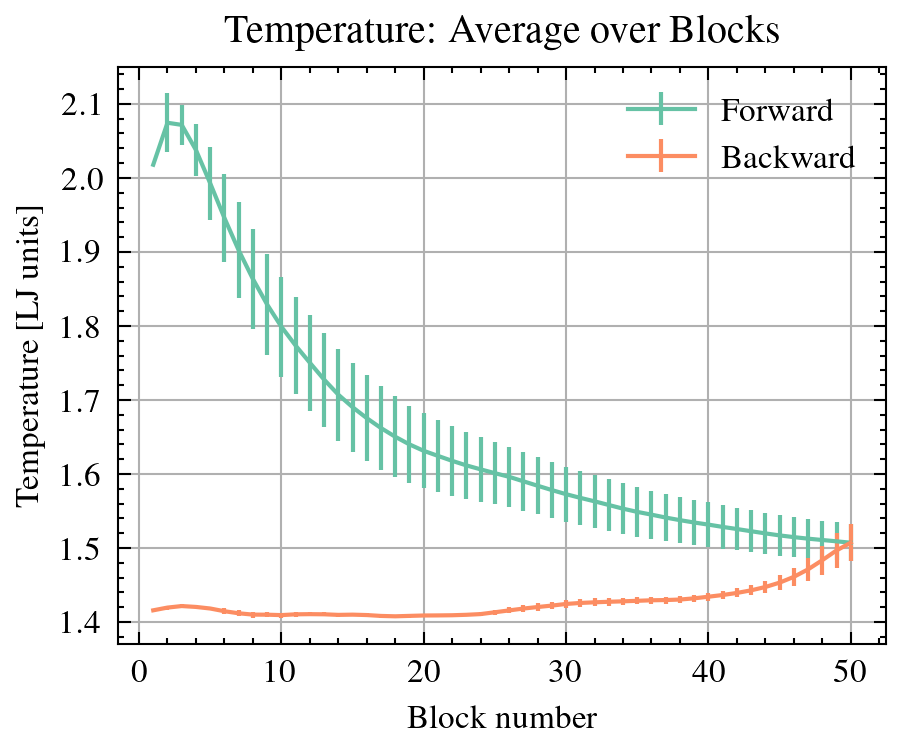

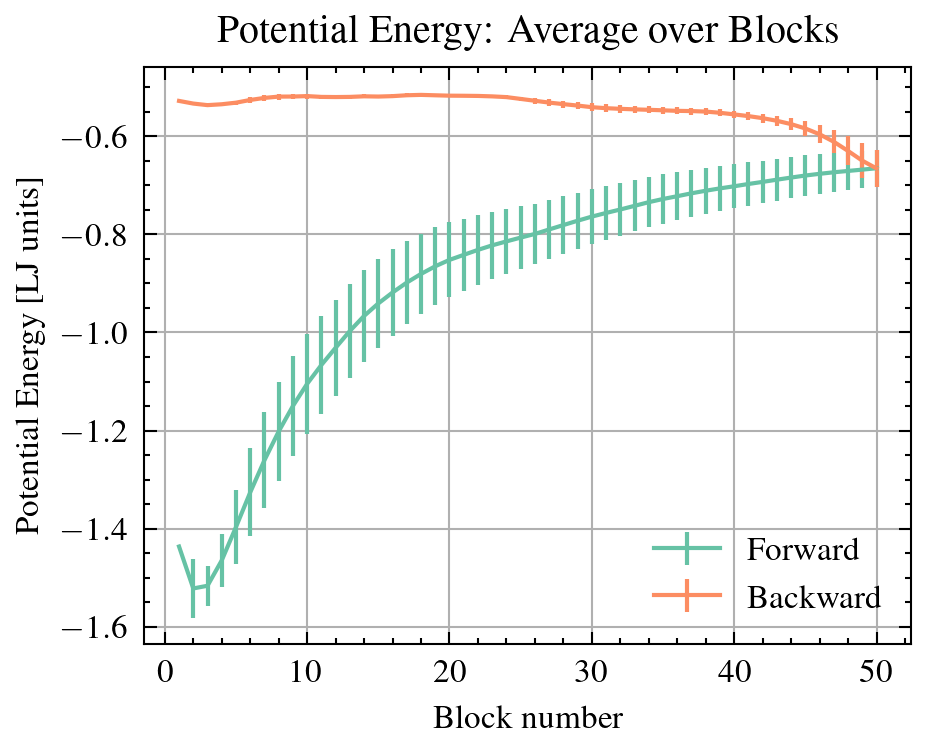

In [6]:
directory = "./Exer_04_03/DATA"

plot_forward_backward(directory, "forward1", "backward1")

We can see that the forward and backward simulations have the final average and error, we suspect that they could have made the same steps in reverse time direction.

A better understanding can be achieved by plotting the average value of each block, and check if they actually repeated the same steps backwards.

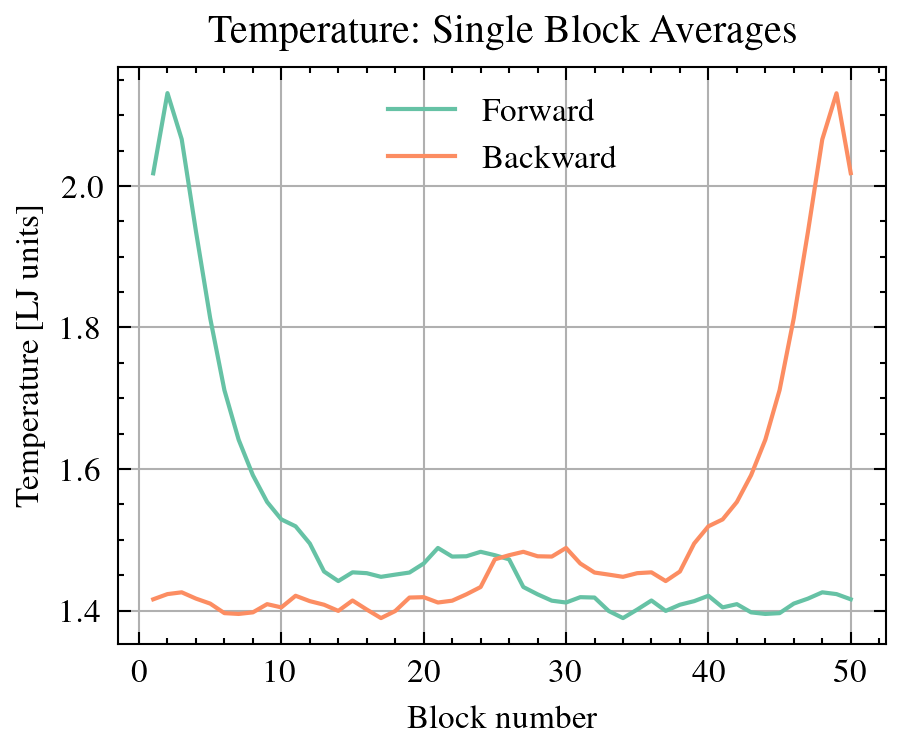

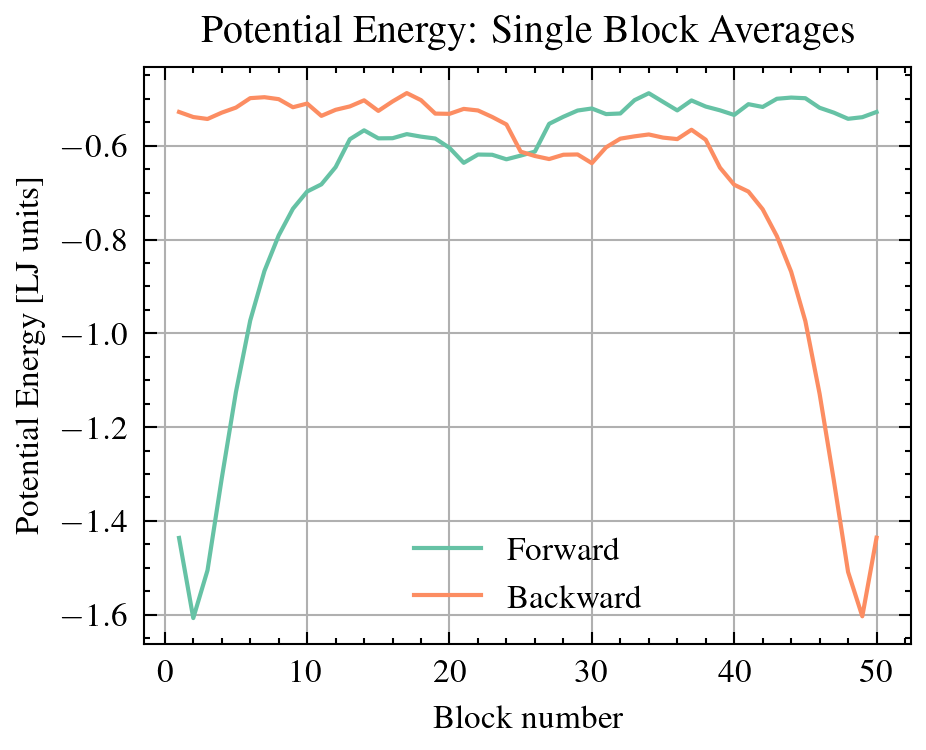

In [7]:
plot_forward_backward(directory, "forward1", "backward1", show_average=False)

As we can see this simulation had exactly the same block averages going forward or backwards in time.

below is a gif of this simulation evolving in time, as we can see at the end it reaches the low entropic configuration of the simulation in the previous exercise.

![backwards](./media/backward1.gif)

### Second simulation (50000 steps)

Now let's do the same things, but increasing the number of steps.

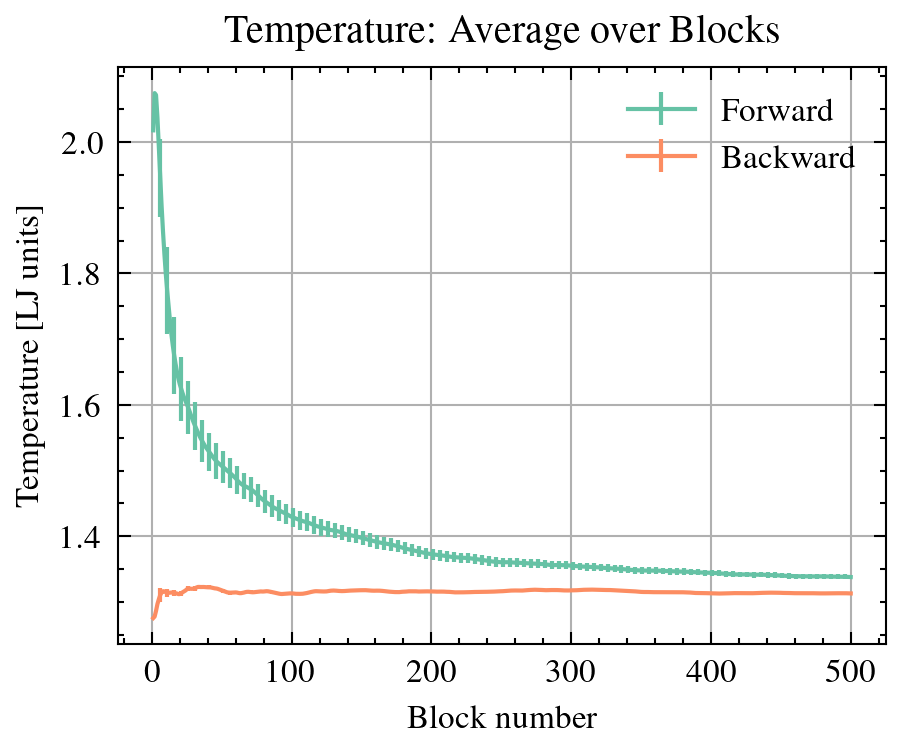

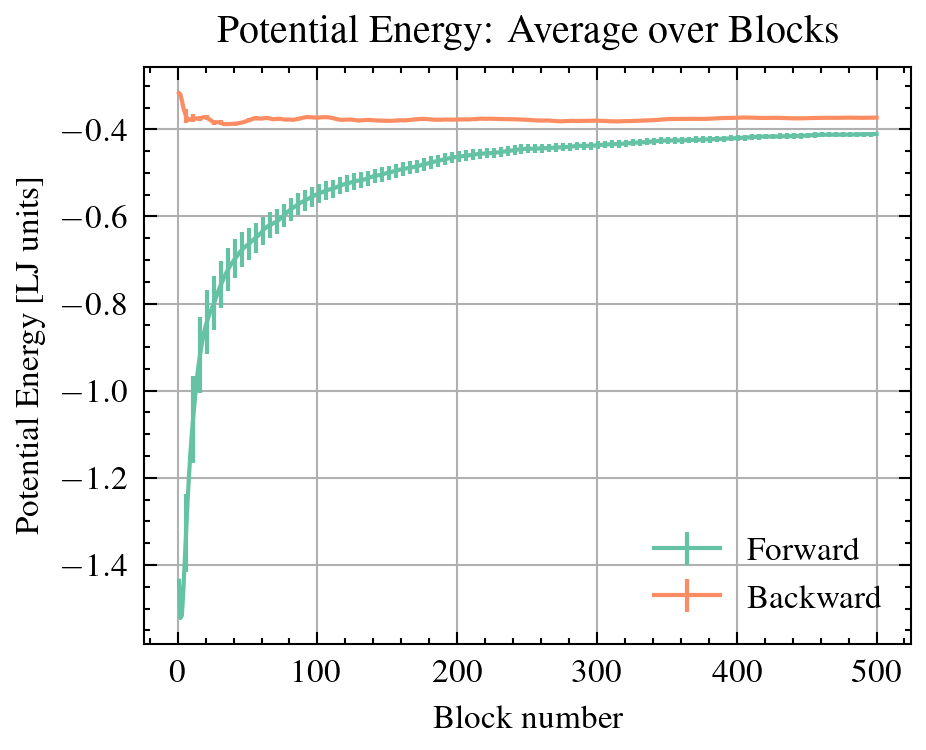

In [8]:
plot_forward_backward(directory, "forward2", "backward2")

We can see that in this case the final average and error are not the same. 

If we plot the instant averages we can get more insight of what happens.

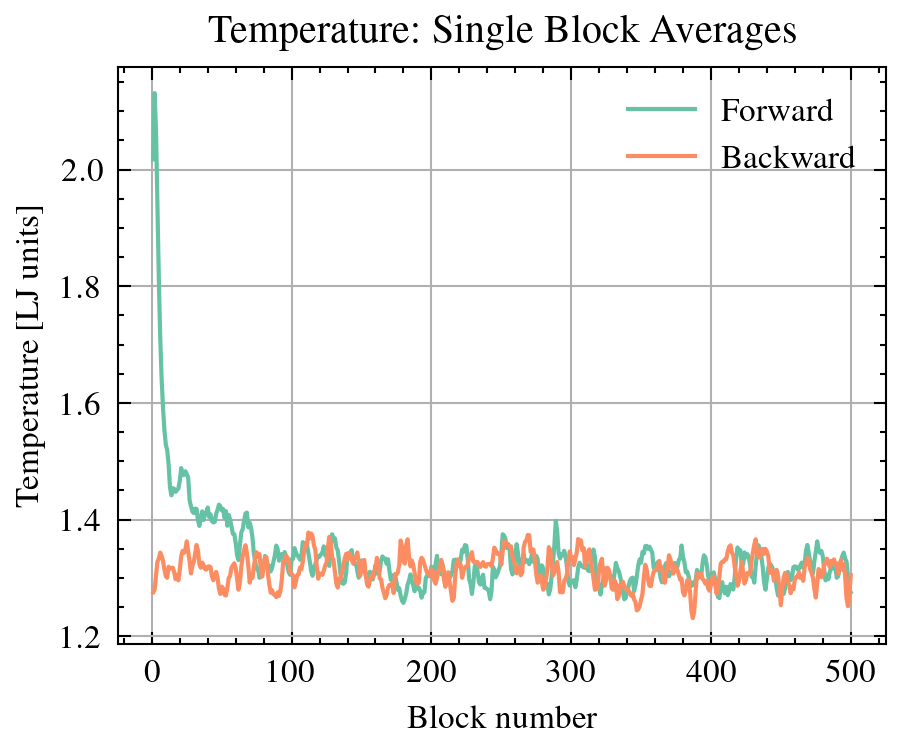

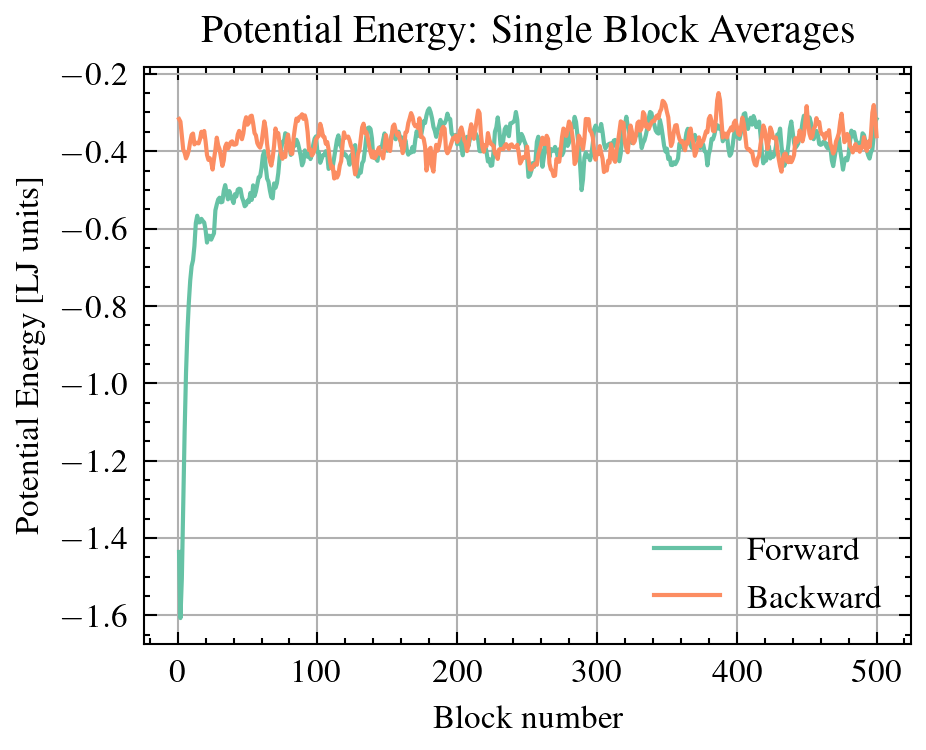

In [9]:
plot_forward_backward(directory, "forward2", "backward2", show_average=False)

As we can see the backward simulation is not reaching the starting configuration.

But the Verlet integrator should go back, we can simply explain this behavior by noticing that computers "suffer" from float point precision errors, so if the simulation evolves in time the particles positions gain a little error over time, which then after reversing time we see that it does not reach the same configuration.

We can see this better if we reverse the block number of the forward configuration, the first few block we expect to see a perfect overlap of the two curves, then they loose coherence over time.

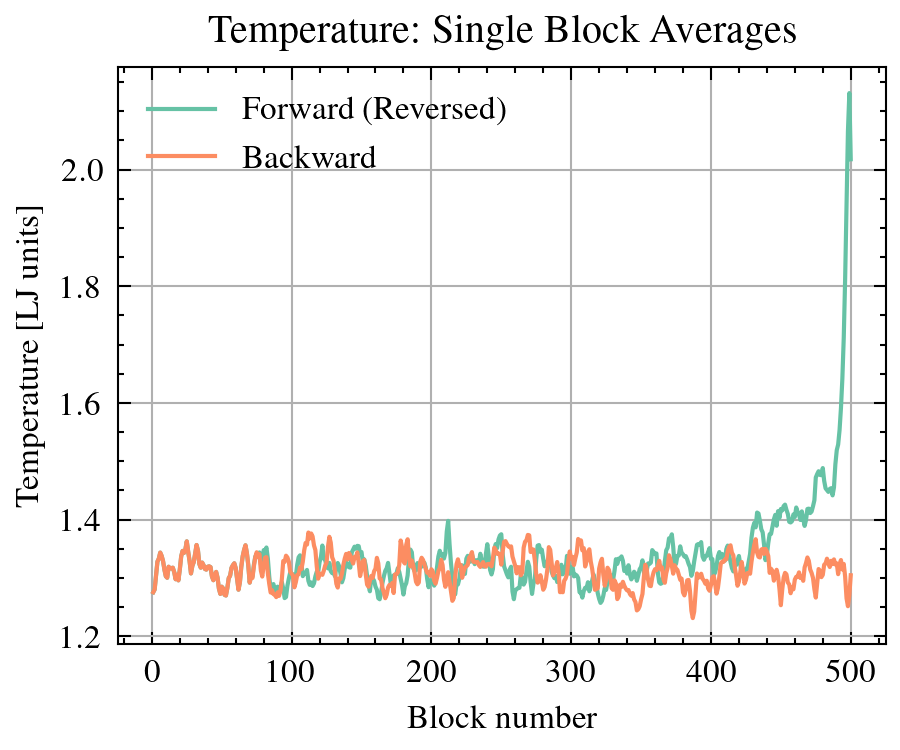

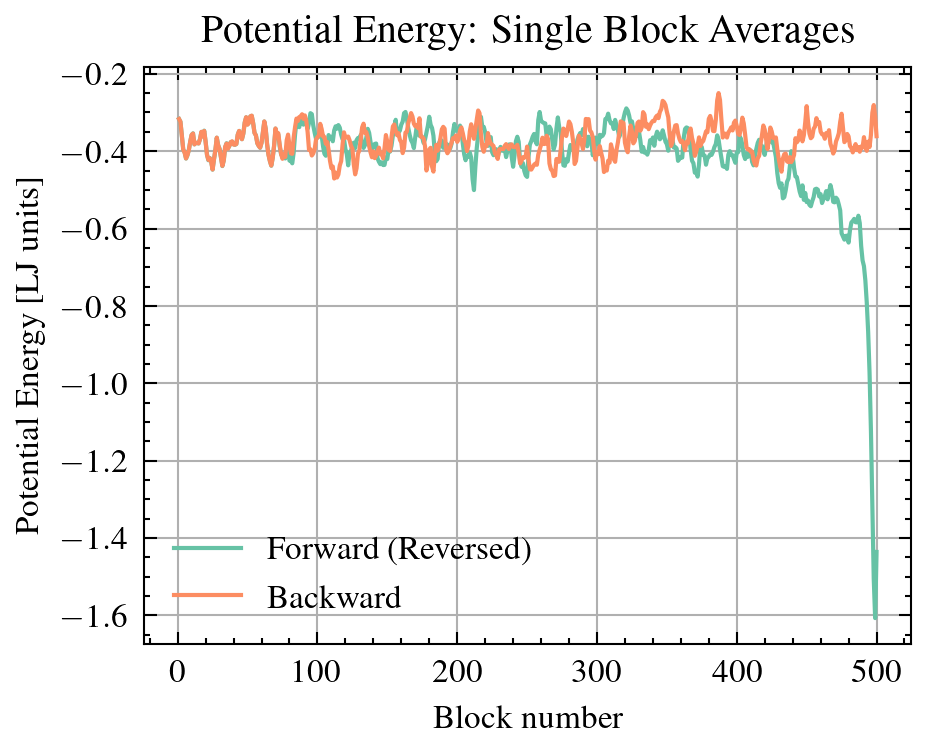

In [10]:
plot_forward_backward(
    directory, "forward2", "backward2", show_average=False, reverse_forward=True
)

As we see from the plots, after around 100 blocks the forward and backward simulations stop to behave in the same manner and start to evolve in a different way.

Ideally if we had a computer with no floating point precision errors we should see the backward simulation reaching the starting point with any number of blocks.